# Skenario 2: Perbandingan Model untuk Deteksi Inkonsistensi

**Pertanyaan Penelitian:** Seberapa besar gap performa antara model pretrained (IndoBERT), model non-pretrained (TextCNN), dan baseline klasik berbasis TF-IDF untuk task deteksi inkonsistensi?

Perbandingan baseline klasik (Logistic Regression, Linear SVC, dan Multinomial Naive Bayes) mengikuti setup eksperimen pada paper [arXiv:2605.03439](https://arxiv.org/html/2605.03439v1#S6): TF-IDF dengan `ngram_range=(1,2)`, `sublinear_tf=True`, `min_df=2`, `max_features=50000`, dan `class_weight='balanced'` untuk menangani ketidakseimbangan kelas.

| Model | Kategori | Cara Handle Rating |
|-------|----------|--------------------|
| TF-IDF + Logistic Regression | Baseline Klasik | Rating sebagai fitur numerik terpisah |
| TF-IDF + Linear SVC | Baseline Klasik | Rating sebagai fitur numerik terpisah |
| TF-IDF + Multinomial Naive Bayes | Baseline Klasik | Rating sebagai fitur numerik terpisah |
| TextCNN | DL non-pretrained | Rating sebagai fitur numerik terpisah |
| IndoBERT Variant C | DL pretrained | `[RATING_X]` sebagai token di awal teks |

## 1. Setup dan Instalasi

In [1]:
import subprocess, sys

packages = [
    'torch', 'transformers', 'scikit-learn',
    'pandas', 'numpy', 'tqdm', 'matplotlib', 'seaborn'
]

for pkg in packages:
    print(f'Installing {pkg}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('Semua library berhasil diinstall.')

Installing torch...
Installing transformers...
Installing scikit-learn...
Installing pandas...
Installing numpy...
Installing tqdm...
Installing matplotlib...
Installing seaborn...
Semua library berhasil diinstall.


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from scipy.sparse import hstack, csr_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, random

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: cuda


## 2. Load dan Persiapan Data

Dataset, labeling, dan split identik dengan Skenario 1 agar perbandingan fair.

In [3]:
df = pd.read_csv('clean_reviews.csv')
print(f'Total data: {len(df):,}')
print(f'Kolom: {list(df.columns)}')
print(f'\nDistribusi label:')
print(df['label'].value_counts())
print(f'\nPersentase inkonsisten: {df["label"].mean()*100:.2f}%')
df.head(3)

Total data: 125,590
Kolom: ['app', 'app_id', 'username', 'rating', 'text', 'text_original', 'thumbs_up', 'date', 'reply', 'lang', 'word_count', 'text_sentiment', 'sentiment_confidence', 'label']

Distribusi label:
label
0    112519
1     13071
Name: count, dtype: int64

Persentase inkonsisten: 10.41%


,app,app_id,username,rating,text,text_original,thumbs_up,date,reply,lang,word_count,text_sentiment,sentiment_confidence,label
0,Gojek,com.gojek.app,Pengguna Google,3,"sorry not sorry, driver yg ga mau jemput saya ...","Sorry not sorry, driver yg ga mau jemput saya ...",0,2026-06-07 09:50:27,"Hai Kak Rose, mohon maaf atas ketidaknyamanann...",id,15,NEGATIVE,1.0,0
1,Gojek,com.gojek.app,Pengguna Google,4,sengaja pesen yang goride comfort biar datengn...,sengaja pesen yang goride comfort biar datengn...,0,2026-06-07 08:49:52,NaN,id,16,NEGATIVE,1.0,1
2,Gojek,com.gojek.app,Pengguna Google,5,"aplikasi yg sangat membantu,tidak ribet,mudah ...","aplikasi yg sangat membantu,tidak ribet,mudah ...",0,2026-06-07 08:45:18,NaN,id,7,POSITIVE,1.0,0


### 2.1 Balancing dan Split (sama dengan Skenario 1)

In [4]:
df_incon = df[df['label'] == 1]
df_con   = df[df['label'] == 0].sample(
    n=min(len(df_incon) * 3, len(df[df['label'] == 0])), random_state=SEED
)

df_balanced = pd.concat([df_incon, df_con]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Dataset balanced: {len(df_balanced):,}')
print(df_balanced['label'].value_counts())

train_df, temp_df = train_test_split(
    df_balanced, test_size=0.3, random_state=SEED, stratify=df_balanced['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label']
)

print(f'\nTrain: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

Dataset balanced: 52,284
label
0    39213
1    13071
Name: count, dtype: int64

Train: 36,598 | Val: 7,843 | Test: 7,843


## 3. Konfigurasi

In [5]:
MODEL_NAME  = 'indobenchmark/indobert-base-p1'
MAX_LEN     = 128
BATCH_SIZE  = 32
EPOCHS      = 5
LR          = 2e-5
NUM_CLASSES = 2

EMBED_DIM    = 128
NUM_FILTERS  = 128
KERNEL_SIZES = [2, 3, 4]
CNN_LR       = 1e-3
CNN_EPOCHS   = 10

TFIDF_MAX_FEATURES = 50000
TFIDF_NGRAM_RANGE  = (1, 2)
TFIDF_MIN_DF       = 2

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

print('Konfigurasi siap.')

Konfigurasi siap.


## 4. Model 1-3: TF-IDF + Classical ML (Baseline Klasik)

Tiga model klasik dibandingkan menggunakan representasi TF-IDF yang sama, mengikuti setup baseline pada paper [arXiv:2605.03439](https://arxiv.org/html/2605.03439v1#S6) (`ngram_range=(1,2)`, `sublinear_tf=True`, `min_df=2`, `max_features=50000`, `class_weight='balanced'` untuk Logistic Regression & Linear SVC). Rating ditambahkan sebagai fitur numerik terpisah, identik dengan pendekatan TextCNN.

### 4.1 Ekstraksi Fitur: TF-IDF + Rating

In [6]:
print('EKSTRAKSI FITUR: TF-IDF + RATING')

tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=TFIDF_NGRAM_RANGE,
    min_df=TFIDF_MIN_DF,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(train_df['text'].astype(str))
X_val_tfidf   = tfidf.transform(val_df['text'].astype(str))
X_test_tfidf  = tfidf.transform(test_df['text'].astype(str))

print(f'Jumlah fitur TF-IDF : {len(tfidf.vocabulary_):,}')


def add_rating_feature(X_sparse, ratings):
    rating_col = csr_matrix(np.array(ratings).reshape(-1, 1) / 5.0)
    return hstack([X_sparse, rating_col])


X_train_cls = add_rating_feature(X_train_tfidf, train_df['rating'].values)
X_val_cls   = add_rating_feature(X_val_tfidf,   val_df['rating'].values)
X_test_cls  = add_rating_feature(X_test_tfidf,  test_df['rating'].values)

print(f'Shape fitur (train) : {X_train_cls.shape}')

EKSTRAKSI FITUR: TF-IDF + RATING
Jumlah fitur TF-IDF : 50,000
Shape fitur (train) : (36598, 50001)


### 4.2 Logistic Regression

In [7]:
print('MODEL 1: TF-IDF + LOGISTIC REGRESSION')

lr_model = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0, class_weight='balanced')
lr_model.fit(X_train_cls, y_train)

lr_val_preds  = lr_model.predict(X_val_cls)
lr_test_preds = lr_model.predict(X_test_cls)

lr_val_acc  = accuracy_score(y_val,  lr_val_preds)
lr_val_f1   = f1_score(y_val,  lr_val_preds, average='weighted')
lr_test_acc = accuracy_score(y_test, lr_test_preds)
lr_test_f1  = f1_score(y_test, lr_test_preds, average='weighted')
lr_test_f1m = f1_score(y_test, lr_test_preds, average='macro')

print(f'\nVal   Acc: {lr_val_acc:.4f} | F1: {lr_val_f1:.4f}')
print(f'Test  Acc: {lr_test_acc:.4f} | F1 (weighted): {lr_test_f1:.4f} | F1 (macro): {lr_test_f1m:.4f}')
print('\nClassification Report (Test):')
print(classification_report(y_test, lr_test_preds, target_names=['Konsisten', 'Inkonsisten']))

MODEL 1: TF-IDF + LOGISTIC REGRESSION

Val   Acc: 0.8997 | F1: 0.9034
Test  Acc: 0.8989 | F1 (weighted): 0.9026 | F1 (macro): 0.8760

Classification Report (Test):
              precision    recall  f1-score   support

   Konsisten       0.98      0.89      0.93      5883
 Inkonsisten       0.73      0.94      0.82      1960

    accuracy                           0.90      7843
   macro avg       0.85      0.91      0.88      7843
weighted avg       0.92      0.90      0.90      7843



### 4.3 Linear SVC

In [8]:
print('MODEL 2: TF-IDF + LINEAR SVC')

svc_model = LinearSVC(C=1.0, class_weight='balanced', random_state=SEED)
svc_model.fit(X_train_cls, y_train)

svc_val_preds  = svc_model.predict(X_val_cls)
svc_test_preds = svc_model.predict(X_test_cls)

svc_val_acc  = accuracy_score(y_val,  svc_val_preds)
svc_val_f1   = f1_score(y_val,  svc_val_preds, average='weighted')
svc_test_acc = accuracy_score(y_test, svc_test_preds)
svc_test_f1  = f1_score(y_test, svc_test_preds, average='weighted')
svc_test_f1m = f1_score(y_test, svc_test_preds, average='macro')

print(f'\nVal   Acc: {svc_val_acc:.4f} | F1: {svc_val_f1:.4f}')
print(f'Test  Acc: {svc_test_acc:.4f} | F1 (weighted): {svc_test_f1:.4f} | F1 (macro): {svc_test_f1m:.4f}')
print('\nClassification Report (Test):')
print(classification_report(y_test, svc_test_preds, target_names=['Konsisten', 'Inkonsisten']))

MODEL 2: TF-IDF + LINEAR SVC

Val   Acc: 0.9008 | F1: 0.9030
Test  Acc: 0.9000 | F1 (weighted): 0.9023 | F1 (macro): 0.8730

Classification Report (Test):
              precision    recall  f1-score   support

   Konsisten       0.96      0.91      0.93      5883
 Inkonsisten       0.76      0.88      0.81      1960

    accuracy                           0.90      7843
   macro avg       0.86      0.89      0.87      7843
weighted avg       0.91      0.90      0.90      7843



### 4.4 Multinomial Naive Bayes

In [9]:
print('MODEL 3: TF-IDF + MULTINOMIAL NAIVE BAYES')

nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_cls, y_train)

nb_val_preds  = nb_model.predict(X_val_cls)
nb_test_preds = nb_model.predict(X_test_cls)

nb_val_acc  = accuracy_score(y_val,  nb_val_preds)
nb_val_f1   = f1_score(y_val,  nb_val_preds, average='weighted')
nb_test_acc = accuracy_score(y_test, nb_test_preds)
nb_test_f1  = f1_score(y_test, nb_test_preds, average='weighted')
nb_test_f1m = f1_score(y_test, nb_test_preds, average='macro')

print(f'\nVal   Acc: {nb_val_acc:.4f} | F1: {nb_val_f1:.4f}')
print(f'Test  Acc: {nb_test_acc:.4f} | F1 (weighted): {nb_test_f1:.4f} | F1 (macro): {nb_test_f1m:.4f}')
print('\nClassification Report (Test):')
print(classification_report(y_test, nb_test_preds, target_names=['Konsisten', 'Inkonsisten']))

MODEL 3: TF-IDF + MULTINOMIAL NAIVE BAYES

Val   Acc: 0.7719 | F1: 0.7078
Test  Acc: 0.7659 | F1 (weighted): 0.7036 | F1 (macro): 0.5450

Classification Report (Test):
              precision    recall  f1-score   support

   Konsisten       0.77      0.98      0.86      5883
 Inkonsisten       0.65      0.14      0.23      1960

    accuracy                           0.77      7843
   macro avg       0.71      0.56      0.54      7843
weighted avg       0.74      0.77      0.70      7843



## 5. Model 4: TextCNN (DL non-pretrained)

In [10]:
from collections import Counter

def build_vocab(texts, max_vocab=30000):
    counter = Counter()
    for text in texts:
        counter.update(str(text).lower().split())
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab

def encode_text(text, vocab, max_len):
    tokens = str(text).lower().split()[:max_len]
    ids    = [vocab.get(t, vocab['<UNK>']) for t in tokens]
    ids   += [vocab['<PAD>']] * (max_len - len(ids))
    return ids

vocab      = build_vocab(train_df['text'].values)
VOCAB_SIZE = len(vocab)
CNN_MAX_LEN= 100

print(f'Vocab size: {VOCAB_SIZE:,}')


class TextCNNDataset(Dataset):
    def __init__(self, texts, ratings, labels, vocab, max_len):
        self.ids     = [encode_text(t, vocab, max_len) for t in texts]
        self.ratings = ratings
        self.labels  = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.ids[idx],     dtype=torch.long),
            'rating':    torch.tensor(self.ratings[idx] / 5.0, dtype=torch.float),
            'label':     torch.tensor(self.labels[idx],  dtype=torch.long)
        }


class TextCNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, kernel_sizes, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs     = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes
        ])
        self.dropout   = nn.Dropout(0.3)
        self.classifier= nn.Sequential(
            nn.Linear(num_filters * len(kernel_sizes) + 1, 128),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, rating):
        x = self.embedding(input_ids).transpose(1, 2)
        pooled = [F.max_pool1d(F.relu(conv(x)), conv(x).size(2)).squeeze(2) for conv in self.convs]
        x = self.dropout(torch.cat(pooled, dim=1))
        return self.classifier(torch.cat([x, rating.unsqueeze(1)], dim=1))


print('TextCNN class siap.')

Vocab size: 30,000
TextCNN class siap.


In [11]:
print('MODEL 4: TextCNN')

train_cnn_ds = TextCNNDataset(train_df['text'].values, train_df['rating'].values, train_df['label'].values, vocab, CNN_MAX_LEN)
val_cnn_ds   = TextCNNDataset(val_df['text'].values,   val_df['rating'].values,   val_df['label'].values,   vocab, CNN_MAX_LEN)
test_cnn_ds  = TextCNNDataset(test_df['text'].values,  test_df['rating'].values,  test_df['label'].values,  vocab, CNN_MAX_LEN)

train_cnn_loader = DataLoader(train_cnn_ds, batch_size=BATCH_SIZE, shuffle=True)
val_cnn_loader   = DataLoader(val_cnn_ds,   batch_size=BATCH_SIZE)
test_cnn_loader  = DataLoader(test_cnn_ds,  batch_size=BATCH_SIZE)

cnn_model   = TextCNNModel(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, KERNEL_SIZES, NUM_CLASSES).to(DEVICE)
cnn_optim   = torch.optim.Adam(cnn_model.parameters(), lr=CNN_LR)
criterion   = nn.CrossEntropyLoss()

cnn_history    = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_cnn_f1    = 0
best_cnn_state = None

for epoch in range(CNN_EPOCHS):
    cnn_model.train()
    t_loss, t_preds, t_labels = 0, [], []
    for batch in tqdm(train_cnn_loader, desc=f'Epoch {epoch+1}/{CNN_EPOCHS} Train', leave=False):
        cnn_optim.zero_grad()
        ids    = batch['input_ids'].to(DEVICE)
        rating = batch['rating'].to(DEVICE)
        labels = batch['label'].to(DEVICE)
        out    = cnn_model(ids, rating)
        loss   = criterion(out, labels)
        loss.backward()
        cnn_optim.step()
        t_loss += loss.item()
        t_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
        t_labels.extend(labels.cpu().numpy())

    cnn_model.eval()
    v_loss, v_preds, v_labels = 0, [], []
    with torch.no_grad():
        for batch in val_cnn_loader:
            ids    = batch['input_ids'].to(DEVICE)
            rating = batch['rating'].to(DEVICE)
            labels = batch['label'].to(DEVICE)
            out    = cnn_model(ids, rating)
            v_loss += criterion(out, labels).item()
            v_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            v_labels.extend(labels.cpu().numpy())

    t_acc = accuracy_score(t_labels, t_preds)
    v_acc = accuracy_score(v_labels, v_preds)
    v_f1  = f1_score(v_labels, v_preds, average='weighted')
    cnn_history['train_loss'].append(t_loss / len(train_cnn_loader))
    cnn_history['val_loss'].append(v_loss / len(val_cnn_loader))
    cnn_history['train_acc'].append(t_acc)
    cnn_history['val_acc'].append(v_acc)

    print(f'Epoch {epoch+1}/{CNN_EPOCHS} | Train Loss: {t_loss/len(train_cnn_loader):.4f} Acc: {t_acc:.4f} | Val Loss: {v_loss/len(val_cnn_loader):.4f} Acc: {v_acc:.4f} F1: {v_f1:.4f}')

    if v_f1 > best_cnn_f1:
        best_cnn_f1    = v_f1
        best_cnn_state = {k: v.clone() for k, v in cnn_model.state_dict().items()}
        print(f'  Best model updated (F1: {best_cnn_f1:.4f})')

cnn_model.load_state_dict(best_cnn_state)
cnn_model.eval()
cnn_test_preds, cnn_test_labels = [], []
with torch.no_grad():
    for batch in test_cnn_loader:
        out = cnn_model(batch['input_ids'].to(DEVICE), batch['rating'].to(DEVICE))
        cnn_test_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
        cnn_test_labels.extend(batch['label'].numpy())

cnn_test_acc = accuracy_score(cnn_test_labels, cnn_test_preds)
cnn_test_f1  = f1_score(cnn_test_labels, cnn_test_preds, average='weighted')
cnn_test_f1m = f1_score(cnn_test_labels, cnn_test_preds, average='macro')

print(f'\n--- Test Results (TextCNN) ---')
print(f'Test Acc: {cnn_test_acc:.4f} | F1 (weighted): {cnn_test_f1:.4f} | F1 (macro): {cnn_test_f1m:.4f}')
print('\nClassification Report (Test):')
print(classification_report(cnn_test_labels, cnn_test_preds, target_names=['Konsisten', 'Inkonsisten']))

MODEL 4: TextCNN


Epoch 1/10 | Train Loss: 0.5037 Acc: 0.7658 | Val Loss: 0.4900 Acc: 0.7815 F1: 0.7322
  Best model updated (F1: 0.7322)


Epoch 2/10 | Train Loss: 0.4201 Acc: 0.8044 | Val Loss: 0.3632 Acc: 0.8340 F1: 0.8234
  Best model updated (F1: 0.8234)


Epoch 3/10 | Train Loss: 0.3337 Acc: 0.8552 | Val Loss: 0.3182 Acc: 0.8606 F1: 0.8535
  Best model updated (F1: 0.8535)


Epoch 4/10 | Train Loss: 0.2572 Acc: 0.8950 | Val Loss: 0.2985 Acc: 0.8860 F1: 0.8858
  Best model updated (F1: 0.8858)


...

Epoch 6/10 | Train Loss: 0.1615 Acc: 0.9375 | Val Loss: 0.3044 Acc: 0.8780 F1: 0.8808


Epoch 7/10 | Train Loss: 0.1288 Acc: 0.9516 | Val Loss: 0.3402 Acc: 0.8819 F1: 0.8797


Epoch 8/10 | Train Loss: 0.1121 Acc: 0.9593 | Val Loss: 0.4135 Acc: 0.8730 F1: 0.8729


Epoch 9/10 | Train Loss: 0.0973 Acc: 0.9633 | Val Loss: 0.4760 Acc: 0.8685 F1: 0.8635


Epoch 10/10 | Train Loss: 0.0812 Acc: 0.9697 | Val Loss: 0.4102 Acc: 0.8655 F1: 0.8647

--- Test Results (TextCNN) ---
Test Acc: 0.8954 | F1 (weighted): 0.8958 | F1 (macro): 0.8616

Classification Report (Test):
              precision    recall  f1-score   support

   Konsisten       0.93      0.93      0.93      5883
 Inkonsisten       0.78      0.80      0.79      1960

    accuracy                           0.90      7843
   macro avg       0.86      0.86      0.86      7843
weighted avg       0.90      0.90      0.90      7843



## 6. Model 5: IndoBERT Variant C (Terbaik dari Skenario 1)

In [12]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded: {MODEL_NAME}')


class DatasetVariantC(Dataset):
    def __init__(self, texts, ratings, labels, tokenizer, max_len):
        self.texts     = [f'[RATING_{r}] {t}' for t, r in zip(texts, ratings)]
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


class ModelVariantC(nn.Module):
    def __init__(self, model_name, num_classes=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(out.last_hidden_state[:, 0, :])


print('Dataset dan Model Variant C siap.')

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded: indobenchmark/indobert-base-p1
Dataset dan Model Variant C siap.


In [13]:
print('MODEL 5: IndoBERT VARIANT C')

train_bert_ds = DatasetVariantC(train_df['text'].values, train_df['rating'].values, train_df['label'].values, tokenizer, MAX_LEN)
val_bert_ds   = DatasetVariantC(val_df['text'].values,   val_df['rating'].values,   val_df['label'].values,   tokenizer, MAX_LEN)
test_bert_ds  = DatasetVariantC(test_df['text'].values,  test_df['rating'].values,  test_df['label'].values,  tokenizer, MAX_LEN)

train_bert_loader = DataLoader(train_bert_ds, batch_size=BATCH_SIZE, shuffle=True)
val_bert_loader   = DataLoader(val_bert_ds,   batch_size=BATCH_SIZE)
test_bert_loader  = DataLoader(test_bert_ds,  batch_size=BATCH_SIZE)

bert_model   = ModelVariantC(MODEL_NAME, NUM_CLASSES).to(DEVICE)
bert_optim   = torch.optim.AdamW(bert_model.parameters(), lr=LR)
bert_crit    = nn.CrossEntropyLoss()

bert_history    = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_bert_f1    = 0
best_bert_state = None

for epoch in range(EPOCHS):
    print(f'\nEpoch {epoch+1}/{EPOCHS}')

    bert_model.train()
    t_loss, t_preds, t_labels = 0, [], []
    for batch in tqdm(train_bert_loader, desc='Training', leave=False):
        bert_optim.zero_grad()
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbl  = batch['label'].to(DEVICE)
        out  = bert_model(ids, mask)
        loss = bert_crit(out, lbl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
        bert_optim.step()
        t_loss += loss.item()
        t_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
        t_labels.extend(lbl.cpu().numpy())

    bert_model.eval()
    v_loss, v_preds, v_labels = 0, [], []
    with torch.no_grad():
        for batch in tqdm(val_bert_loader, desc='Evaluating', leave=False):
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            lbl  = batch['label'].to(DEVICE)
            out  = bert_model(ids, mask)
            v_loss += bert_crit(out, lbl).item()
            v_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            v_labels.extend(lbl.cpu().numpy())

    t_acc = accuracy_score(t_labels, t_preds)
    v_acc = accuracy_score(v_labels, v_preds)
    v_f1  = f1_score(v_labels, v_preds, average='weighted')
    bert_history['train_loss'].append(t_loss / len(train_bert_loader))
    bert_history['val_loss'].append(v_loss / len(val_bert_loader))
    bert_history['train_acc'].append(t_acc)
    bert_history['val_acc'].append(v_acc)

    print(f'  Train Loss: {t_loss/len(train_bert_loader):.4f} | Acc: {t_acc:.4f}')
    print(f'  Val   Loss: {v_loss/len(val_bert_loader):.4f} | Acc: {v_acc:.4f} | F1: {v_f1:.4f}')

    if v_f1 > best_bert_f1:
        best_bert_f1    = v_f1
        best_bert_state = {k: v.clone() for k, v in bert_model.state_dict().items()}
        print(f'  Best model updated (F1: {best_bert_f1:.4f})')

bert_model.load_state_dict(best_bert_state)
bert_model.eval()
bert_test_preds, bert_test_labels = [], []
with torch.no_grad():
    for batch in tqdm(test_bert_loader, desc='Testing', leave=False):
        out = bert_model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
        bert_test_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
        bert_test_labels.extend(batch['label'].numpy())

bert_test_acc = accuracy_score(bert_test_labels, bert_test_preds)
bert_test_f1  = f1_score(bert_test_labels, bert_test_preds, average='weighted')
bert_test_f1m = f1_score(bert_test_labels, bert_test_preds, average='macro')

print(f'\n--- Test Results (IndoBERT Variant C) ---')
print(f'Test Acc: {bert_test_acc:.4f} | F1 (weighted): {bert_test_f1:.4f} | F1 (macro): {bert_test_f1m:.4f}')
print('\nClassification Report (Test):')
print(classification_report(bert_test_labels, bert_test_preds, target_names=['Konsisten', 'Inkonsisten']))

MODEL 5: IndoBERT VARIANT C


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Epoch 1/5


Training:   0%|          | 0/1144 [00:00<?, ?it/s]

...

  Train Loss: 0.0829 | Acc: 0.9727
  Val   Loss: 0.1032 | Acc: 0.9619 | F1: 0.9620
  Best model updated (F1: 0.9620)

Epoch 3/5


  Train Loss: 0.0534 | Acc: 0.9839
  Val   Loss: 0.1700 | Acc: 0.9600 | F1: 0.9604

Epoch 4/5


  Train Loss: 0.0356 | Acc: 0.9902
  Val   Loss: 0.2178 | Acc: 0.9583 | F1: 0.9580

Epoch 5/5


  Train Loss: 0.0245 | Acc: 0.9939
  Val   Loss: 0.2013 | Acc: 0.9615 | F1: 0.9614



--- Test Results (IndoBERT Variant C) ---
Test Acc: 0.9619 | F1 (weighted): 0.9621 | F1 (macro): 0.9497

Classification Report (Test):
              precision    recall  f1-score   support

   Konsisten       0.98      0.97      0.97      5883
 Inkonsisten       0.91      0.94      0.92      1960

    accuracy                           0.96      7843
   macro avg       0.95      0.95      0.95      7843
weighted avg       0.96      0.96      0.96      7843



## 7. Perbandingan Hasil Kelima Model

In [14]:
print('PERBANDINGAN HASIL KELIMA MODEL')

comparison = pd.DataFrame({
    'Model':              ['TF-IDF + LR', 'TF-IDF + LinearSVC', 'TF-IDF + MultinomialNB', 'TextCNN', 'IndoBERT (Var C)'],
    'Kategori':           ['Baseline Klasik', 'Baseline Klasik', 'Baseline Klasik', 'DL non-pretrained', 'DL pretrained'],
    'Test Accuracy':      [lr_test_acc,  svc_test_acc,  nb_test_acc,  cnn_test_acc,  bert_test_acc],
    'Test F1 (Weighted)': [lr_test_f1,   svc_test_f1,   nb_test_f1,   cnn_test_f1,   bert_test_f1],
    'Test F1 (Macro)':    [lr_test_f1m,  svc_test_f1m,  nb_test_f1m,  cnn_test_f1m,  bert_test_f1m],
})
for col in ['Test Accuracy', 'Test F1 (Weighted)', 'Test F1 (Macro)']:
    comparison[col] = comparison[col].round(4)
display(comparison)

best_row = comparison.loc[comparison['Test F1 (Weighted)'].idxmax()]
print(f'\nModel terbaik         : {best_row["Model"]}')
print(f'  Accuracy            : {best_row["Test Accuracy"]:.4f}')
print(f'  F1-Score (Weighted) : {best_row["Test F1 (Weighted)"]:.4f}')
print(f'  F1-Score (Macro)    : {best_row["Test F1 (Macro)"]:.4f}')

best_klasik_f1 = comparison.loc[comparison['Kategori'] == 'Baseline Klasik', 'Test F1 (Weighted)'].max()
best_klasik_row = comparison.loc[comparison['Kategori'] == 'Baseline Klasik'].sort_values('Test F1 (Weighted)', ascending=False).iloc[0]

gap_bert_cnn   = bert_test_f1 - cnn_test_f1
gap_cnn_klasik = cnn_test_f1 - best_klasik_f1

print(f'\nBaseline klasik terbaik              : {best_klasik_row["Model"]} (F1: {best_klasik_f1:.4f})')
print(f'Gap F1 (IndoBERT vs TextCNN)         : {gap_bert_cnn:+.4f}')
print(f'Gap F1 (TextCNN vs Baseline Klasik)  : {gap_cnn_klasik:+.4f}')

PERBANDINGAN HASIL KELIMA MODEL


,Model,Kategori,Test Accuracy,Test F1 (Weighted),Test F1 (Macro)
0,TF-IDF + LR,Baseline Klasik,0.8989,0.9026,0.8760
1,TF-IDF + LinearSVC,Baseline Klasik,0.9000,0.9023,0.8730
2,TF-IDF + MultinomialNB,Baseline Klasik,0.7659,0.7036,0.5450
3,TextCNN,DL non-pretrained,0.8954,0.8958,0.8616
4,IndoBERT (Var C),DL pretrained,0.9619,0.9621,0.9497



Model terbaik         : IndoBERT (Var C)
  Accuracy            : 0.9619
  F1-Score (Weighted) : 0.9621
  F1-Score (Macro)    : 0.9497

Baseline klasik terbaik              : TF-IDF + LR (F1: 0.9026)
Gap F1 (IndoBERT vs TextCNN)         : +0.0662
Gap F1 (TextCNN vs Baseline Klasik)  : -0.0068


## 8. Visualisasi

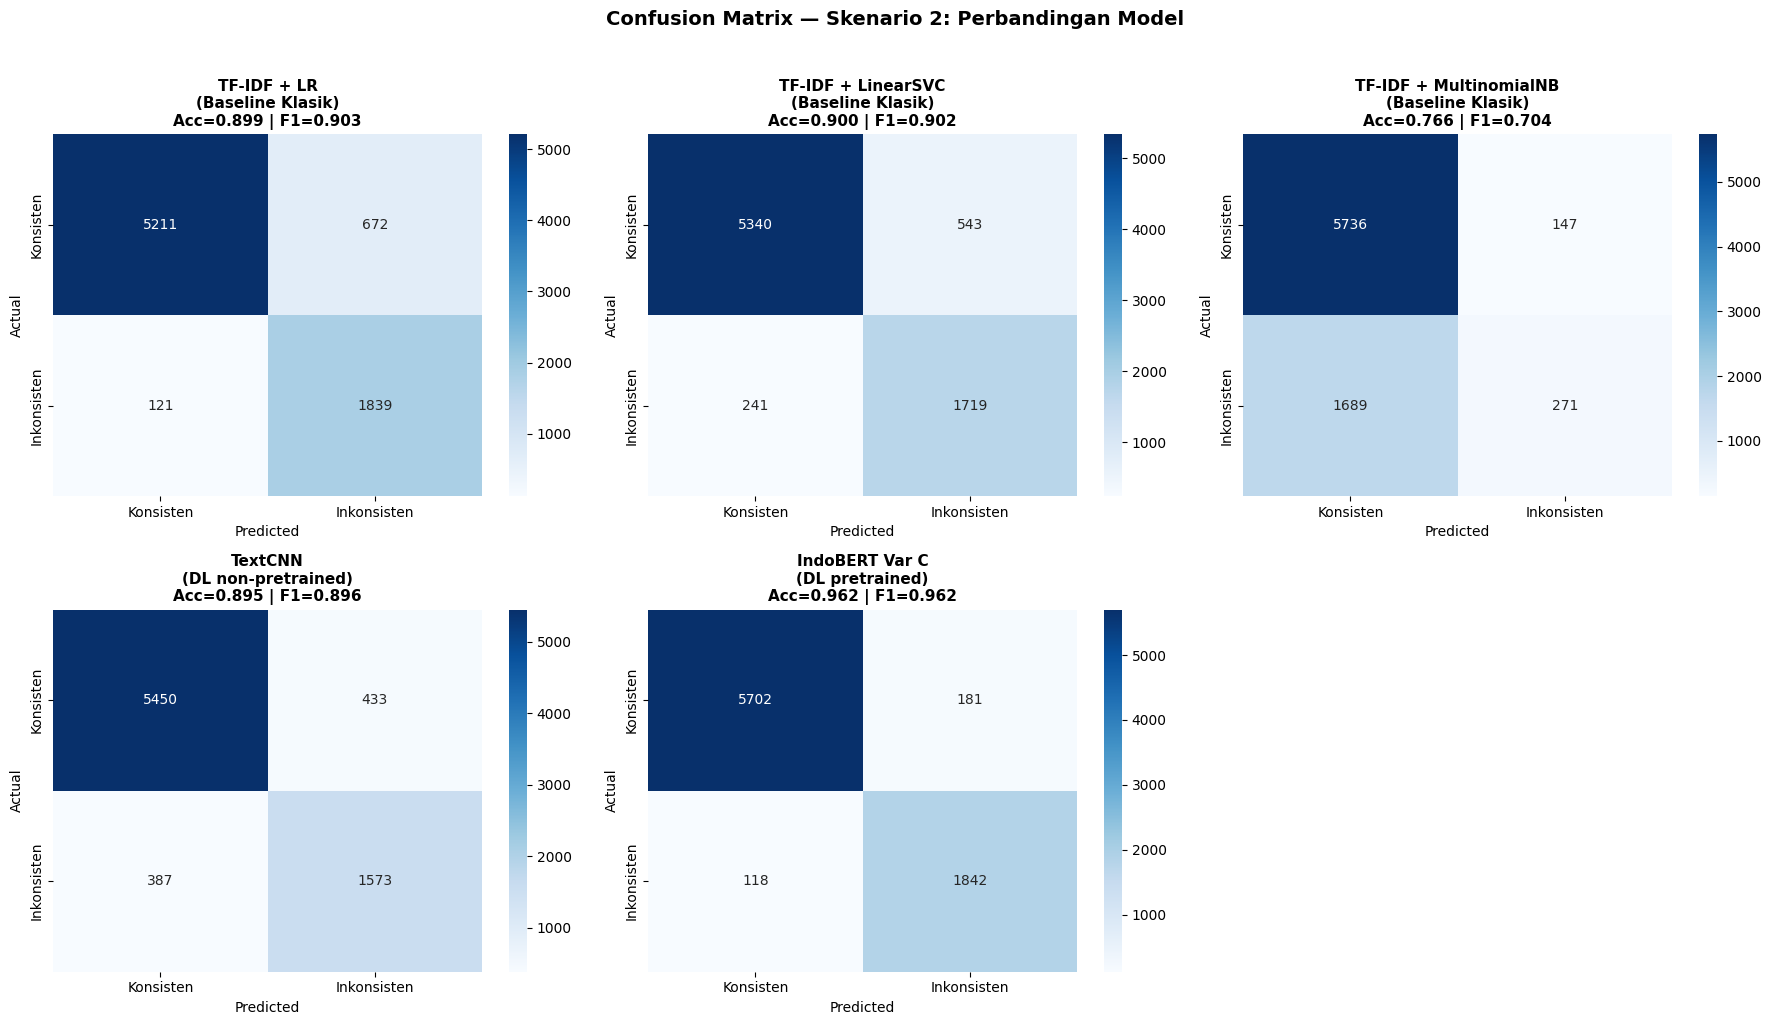

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

model_results = [
    ('TF-IDF + LR\n(Baseline Klasik)',           y_test,           lr_test_preds,   lr_test_acc,  lr_test_f1),
    ('TF-IDF + LinearSVC\n(Baseline Klasik)',    y_test,           svc_test_preds,  svc_test_acc, svc_test_f1),
    ('TF-IDF + MultinomialNB\n(Baseline Klasik)', y_test,          nb_test_preds,   nb_test_acc,  nb_test_f1),
    ('TextCNN\n(DL non-pretrained)',             cnn_test_labels,  cnn_test_preds,  cnn_test_acc, cnn_test_f1),
    ('IndoBERT Var C\n(DL pretrained)',          bert_test_labels, bert_test_preds, bert_test_acc, bert_test_f1),
]

for i, (title, true, pred, acc, f1) in enumerate(model_results):
    ax = axes[i]
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Konsisten', 'Inkonsisten'],
                yticklabels=['Konsisten', 'Inkonsisten'])
    ax.set_title(f'{title}\nAcc={acc:.3f} | F1={f1:.3f}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

for j in range(len(model_results), len(axes)):
    axes[j].axis('off')

plt.suptitle('Confusion Matrix — Skenario 2: Perbandingan Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

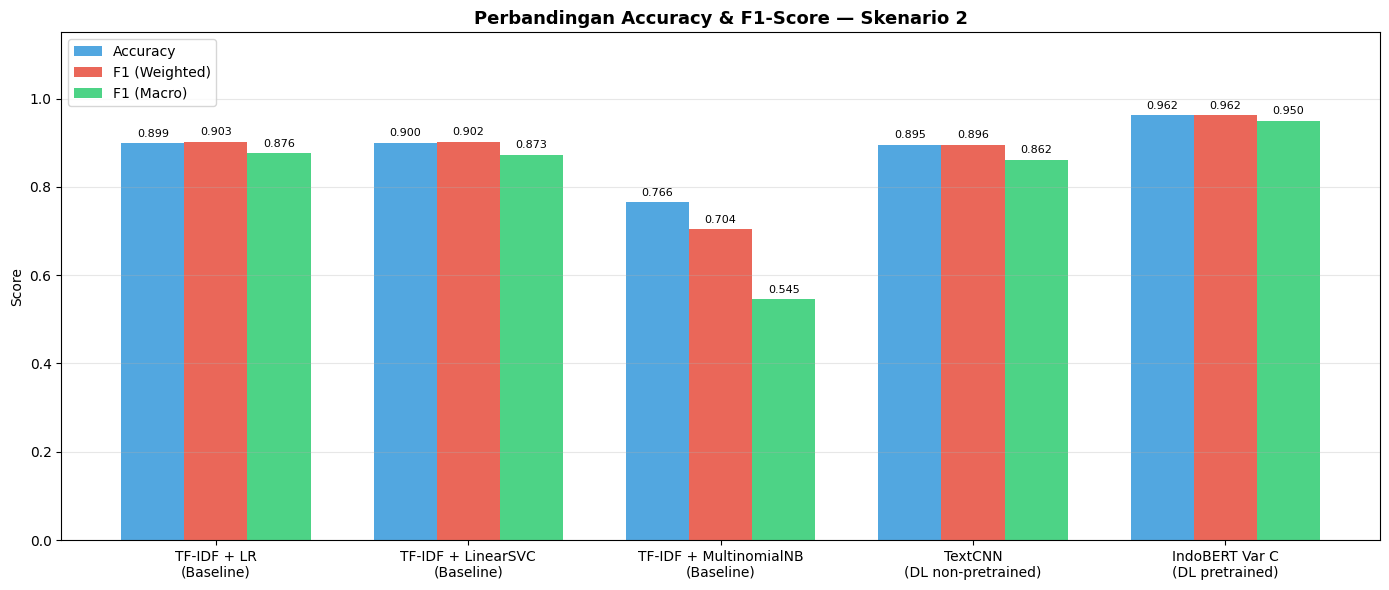

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

x        = np.arange(5)
width    = 0.25
labels_x = ['TF-IDF + LR\n(Baseline)', 'TF-IDF + LinearSVC\n(Baseline)', 'TF-IDF + MultinomialNB\n(Baseline)',
             'TextCNN\n(DL non-pretrained)', 'IndoBERT Var C\n(DL pretrained)']
acc_vals = [lr_test_acc,  svc_test_acc,  nb_test_acc,  cnn_test_acc,  bert_test_acc]
f1w_vals = [lr_test_f1,   svc_test_f1,   nb_test_f1,   cnn_test_f1,   bert_test_f1]
f1m_vals = [lr_test_f1m,  svc_test_f1m,  nb_test_f1m,  cnn_test_f1m,  bert_test_f1m]

bars1 = ax.bar(x - width, acc_vals, width, label='Accuracy',      color='#3498db', alpha=0.85)
bars2 = ax.bar(x,         f1w_vals, width, label='F1 (Weighted)', color='#e74c3c', alpha=0.85)
bars3 = ax.bar(x + width, f1m_vals, width, label='F1 (Macro)',    color='#2ecc71', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels_x, fontsize=10)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Accuracy & F1-Score — Skenario 2', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.15)
ax.grid(True, axis='y', alpha=0.3)

for bars in (bars1, bars2, bars3):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

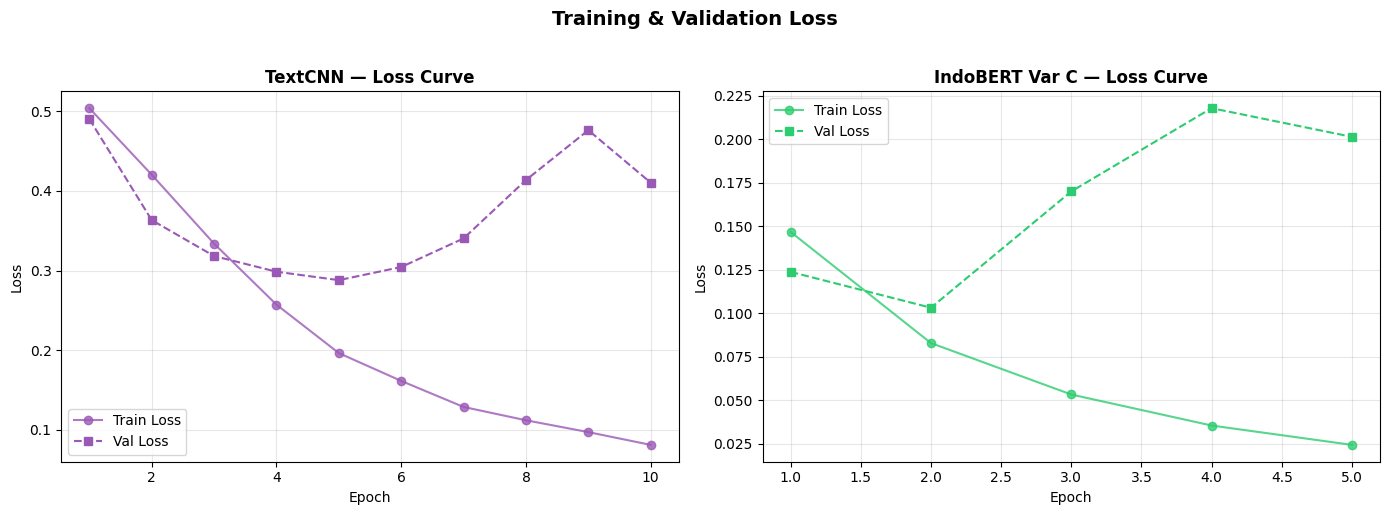

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(range(1, CNN_EPOCHS+1), cnn_history['train_loss'], '-o', label='Train Loss', color='#9b59b6', alpha=0.8)
ax.plot(range(1, CNN_EPOCHS+1), cnn_history['val_loss'],   '--s', label='Val Loss',  color='#9b59b6')
ax.set_title('TextCNN — Loss Curve', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(range(1, EPOCHS+1), bert_history['train_loss'], '-o', label='Train Loss', color='#2ecc71', alpha=0.8)
ax.plot(range(1, EPOCHS+1), bert_history['val_loss'],   '--s', label='Val Loss',  color='#2ecc71')
ax.set_title('IndoBERT Var C — Loss Curve', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Training & Validation Loss', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Kesimpulan

### 9.1 Hasil

| Model | Kategori | Test Accuracy | F1 (Weighted) | F1 (Macro) |
|-------|----------|---------------|----------------|-------------|
| TF-IDF + Logistic Regression | Baseline Klasik | 0.8989 | 0.9026 | 0.8760 |
| TF-IDF + Linear SVC | Baseline Klasik | 0.9000 | 0.9023 | 0.8730 |
| TF-IDF + Multinomial Naive Bayes | Baseline Klasik | 0.7659 | 0.7036 | 0.5450 |
| TextCNN | DL non-pretrained | 0.8954 | 0.8958 | 0.8616 |
| **IndoBERT Variant C** | DL pretrained | **0.9619** | **0.9621** | **0.9497** |

### 9.2 Temuan Utama

1. **IndoBERT Variant C unggul jauh di semua metrik**, terutama pada F1-Macro (0.9497) yang menjadi metrik utama paper rujukan karena dataset timpang (rasio konsisten:inkonsisten ≈ 3:1). Gap F1-Macro terhadap model terbaik kedua (TF-IDF + LR, 0.8760) mencapai **+0.0737**, menegaskan kontribusi representasi kontekstual pretrained dalam menangkap inkonsistensi sentimen-rating yang halus — termasuk pada kelas minoritas "Inkonsisten" (recall 0.94, F1 0.92).

2. **TextCNN (DL non-pretrained) tidak mengungguli baseline klasik TF-IDF**. Dengan jumlah data latih yang besar (36.598 sampel), TF-IDF + Logistic Regression/Linear SVC dengan `class_weight='balanced'` justru sedikit lebih baik daripada TextCNN, baik dari F1-Weighted (gap **-0.0068**) maupun F1-Macro (0.8760/0.8730 vs 0.8616). Ini menunjukkan bahwa embedding yang dilatih dari nol tanpa pretraining tidak memberi keunggulan dibanding representasi n-gram TF-IDF yang sudah ditangani ketidakseimbangan kelasnya.

3. **TF-IDF + Logistic Regression dan Linear SVC berperforma hampir identik** dan menjadi baseline klasik terbaik (F1-Macro 0.8760 vs 0.8730), berkat `class_weight='balanced'` yang membuat keduanya cukup sensitif terhadap kelas "Inkonsisten" (recall 0.94 untuk LR, 0.88 untuk Linear SVC).

4. **TF-IDF + Multinomial Naive Bayes jauh paling lemah** (F1-Macro hanya 0.5450). Tanpa dukungan `class_weight`, model ini sangat bias ke kelas mayoritas "Konsisten" — recall kelas "Inkonsisten" hanya 0.14 (F1 0.23), meski precision-nya 0.65. Asumsi independensi fitur pada Naive Bayes tampaknya kurang cocok untuk fitur TF-IDF berdimensi tinggi (50.000 fitur) yang dikombinasikan dengan data timpang.

### 9.3 Implikasi

Gap performa antara model **pretrained (IndoBERT) vs non-pretrained/klasik** sangat signifikan (+0.066 hingga +0.090 pada F1-Macro), menunjukkan bahwa untuk task deteksi inkonsistensi sentimen-rating yang membutuhkan pemahaman konteks bahasa, representasi pretrained masih menjadi faktor pembeda utama. Sebaliknya, gap antar model non-pretrained relatif kecil bahkan terbalik (TextCNN < TF-IDF+LR), sehingga **penambahan kompleksitas arsitektur (CNN) tanpa pretraining tidak menjamin peningkatan performa** dibanding baseline klasik yang ditangani ketidakseimbangan kelasnya dengan baik.

Label inkonsistensi bersumber dari `clean_reviews.csv` yang dihasilkan oleh `preprocess.ipynb` menggunakan model pretrained `mdhugol/indonesia-bert-sentiment-classification` sebagai labeler. Setup baseline klasik (TF-IDF `ngram_range=(1,2)`, `sublinear_tf=True`, `min_df=2`, `max_features=50000`, `class_weight='balanced'`) mengikuti paper [arXiv:2605.03439](https://arxiv.org/html/2605.03439v1#S6).